In [ ]:
%cd /content
!rm -rf D-GCAN

/content


In [ ]:

!ls /content

sample_data


In [6]:
%cd /content
!git clone https://github.com/JinYSun/D-GCAN.git

/content
Cloning into 'D-GCAN'...
remote: Enumerating objects: 493, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 493 (delta 31), reused 30 (delta 14), pack-reused 441 (from 1)
Receiving objects: 100% (493/493), 7.53 MiB | 10.01 MiB/s, done.
Resolving deltas: 100% (278/278), done.


In [ ]:
!find D-GCAN -maxdepth 2

D-GCAN
D-GCAN/Discussion
D-GCAN/Discussion/RF.py
D-GCAN/Discussion/svc.py
D-GCAN/Discussion/GPC.py
D-GCAN/Discussion/preprocess.py
D-GCAN/Discussion/GNN.py
D-GCAN/Discussion/CNN.py
D-GCAN/solgan.png
D-GCAN/.git
D-GCAN/.git/description
D-GCAN/.git/config
D-GCAN/.git/refs
D-GCAN/.git/HEAD
D-GCAN/.git/info
D-GCAN/.git/branches
D-GCAN/.git/index
D-GCAN/.git/packed-refs
D-GCAN/.git/objects
D-GCAN/.git/hooks
D-GCAN/.git/logs
D-GCAN/.gitignore
D-GCAN/dataset
D-GCAN/dataset/data_train.txt
D-GCAN/dataset/nonUS.txt
D-GCAN/dataset/withdrawn.txt
D-GCAN/dataset/data_test.txt
D-GCAN/dataset/bRo5.txt
D-GCAN/Tutorial.ipynb
D-GCAN/README.md
D-GCAN/Test
D-GCAN/Test/test.ipynb
D-GCAN/screening
D-GCAN/screening/ADMET.ipynb
D-GCAN/screening/process.png
D-GCAN/screening/Dataset
D-GCAN/screening/README.md
D-GCAN/screening/COVIDVS-3.ipynb
D-GCAN/screening/DTI.ipynb
D-GCAN/LICENSE
D-GCAN/DGCAN
D-GCAN/DGCAN/run.py
D-GCAN/DGCAN/__init__.py
D-GCAN/DGCAN/dict
D-GCAN/DGCAN/DGCAN.py
D-GCAN/DGCAN/Tutorial.ipynb
D-GCA

In [7]:
%cd /content/D-GCAN/DGCAN
!pwd
!ls


/content/D-GCAN/DGCAN
/content/D-GCAN/DGCAN
DGCAN.py  __init__.py  preprocess.py  run.py	Tutorial.ipynb
dict	  predict.py   results	      train.py


In [ ]:
!grep -n "file_model" train.py
!grep -n "file_result" train.py


123:    file_model = '../DGCAN/model/model' + '.pth'
155:        tester.save_model(model, file_model)
118:    file_result = path + '../DGCAN/results/AUC' + '.txt'
119:    #    file_result = '../output/result--' + setting + '.txt'
124:    with open(file_result, 'w') as f:
154:        tester.save_result(result, file_result)


In [ ]:
import os

os.makedirs("model", exist_ok=True)

print(os.getcwd())
print(os.path.exists("model"))

/content/D-GCAN/DGCAN
True


In [ ]:
import os
print(os.path.abspath("../DGCAN/model/model.pth"))


/content/D-GCAN/DGCAN/model/model.pth


In [ ]:
!sed -i "s|../DGCAN/model/model|model/model|g" train.py

In [ ]:
!grep -n "file_model" train.py

123:    file_model = 'model/model' + '.pth'
155:        tester.save_model(model, file_model)


In [ ]:
import os
os.makedirs("model", exist_ok=True)

In [ ]:
!ls

DGCAN.py  __init__.py  predict.py     results  train.py
dict	  model        preprocess.py  run.py   Tutorial.ipynb


In [ ]:
print(os.path.abspath("../DGCAN/model/model.pth"))
!grep -n "file_model" train.py

/content/D-GCAN/DGCAN/model/model.pth
123:    file_model = 'model/model' + '.pth'
155:        tester.save_model(model, file_model)


In [ ]:
!ls

DGCAN.py  __init__.py  predict.py     results  train.py
dict	  model        preprocess.py  run.py   Tutorial.ipynb


In [ ]:
import train

test = train.train(
    '../dataset/bRo5.txt',
    radius=1,
    dim=52,
    layer_hidden=4,
    layer_output=10,
    dropout=0.45,
    batch_train=8,
    batch_test=8,
    lr=3e-4,
    lr_decay=0.85,
    decay_interval=25,
    iteration=10,
    N=5000,
    dataset_train='../dataset/data_train.txt'
)

The code uses a GPU!
----------------------------------------------------------------------------------------------------
Just a moment......
----------------------------------------------------------------------------------------------------
../dataset/data_train.txt
../dataset/bRo5.txt
The preprocess has finished!
----------------------------------------------------------------------------------------------------
Creating a model.
# of model parameters: 311698
----------------------------------------------------------------------------------------------------
Start training.
The result is saved in the output directory every epoch!
The training will finish in about 0 hours 1 minutes.
----------------------------------------------------------------------------------------------------
Epoch	Time(sec)	Loss_train	Loss_test	AUC_train	AUC_test
1	8.09617080299995	318.32105273008347	20.28933635354042	0.6240720548187837	0.5173745173745173
2	15.798214327999858	279.60529312491417	16.091720610857

In [ ]:
test = train.train(
    '../dataset/bRo5.txt',
    radius=1,
    dim=52,
    layer_hidden=4,
    layer_output=10,
    dropout=0.45,
    batch_train=8,
    batch_test=8,
    lr=3e-4,
    lr_decay=0.85,
    decay_interval=25,
    iteration=50,      # changed from 10
    N=5000,
    dataset_train='../dataset/data_train.txt'
)

The code uses a GPU!
----------------------------------------------------------------------------------------------------
Just a moment......
----------------------------------------------------------------------------------------------------
../dataset/data_train.txt
../dataset/bRo5.txt
The preprocess has finished!
----------------------------------------------------------------------------------------------------
Creating a model.
# of model parameters: 311698
----------------------------------------------------------------------------------------------------
Start training.
The result is saved in the output directory every epoch!
The training will finish in about 0 hours 6 minutes.
----------------------------------------------------------------------------------------------------
Epoch	Time(sec)	Loss_train	Loss_test	AUC_train	AUC_test
1	8.082472742999926	318.32105273008347	20.28933635354042	0.6240720548187837	0.5173745173745173
2	16.118845391999912	279.60529312491417	16.09172061085

In [ ]:
!cp model/model.pth model/dgcan_baseline.pth

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p "/content/drive/MyDrive/DGCAN_Project"
!cp model/dgcan_baseline.pth "/content/drive/MyDrive/DGCAN_Project/"

In [ ]:
!cp results/AUC.txt "/content/drive/MyDrive/DGCAN_Project/"

In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.8 MB/s eta 0:00:00


In [ ]:
!cp DGCAN.py DGCAN_backup.py

In [ ]:
!grep -n "class GraphAttentionLayer" DGCAN.py

31:class GraphAttentionLayer(nn.Module):


In [ ]:
!grep -n "def forward(self, input, adj)" DGCAN.py


47:    def forward(self, input, adj):   


In [ ]:
!sed -n '47,75p' DGCAN.py

    def forward(self, input, adj):   
        """
        input: input_feature [N, in_features] in_features indicates the number of elements of the input feature vector of the node
        adj: adjacency matrix of the graph dimension [N, N] non-zero is one, data structure basics
        """
        h = torch.mm(input, self.W)    # [N, out_features]
        N = h.size()[0]     #Number of nodes of the graph
        a_input = torch.cat([h.repeat(1, N).view(N * N, -1), h.repeat(N, 1)], dim=1).view(N, -1, 2 * self.out_features)     # [N, N, 2*out_features]
        e = self.leakyrelu(torch.matmul(a_input, self.a).squeeze(2))
        zero_vec =-9e10 *torch.ones_like(e)
        attention = torch.where(adj > 0, e, zero_vec)    
        # indicates that if the adjacency matrix element is greater than 0, then the two nodes are connected and the attention factor at that position is retained.
        # Otherwise it is necessary to mask and set to a very small value, the reason is that this minimum 

In [ ]:
def forward(self, input, adj):
    h = torch.mm(input, self.W)
    N = h.size()[0]

    a_input = torch.cat(
        [h.repeat(1, N).view(N * N, -1), h.repeat(N, 1)],
        dim=1
    ).view(N, -1, 2 * self.out_features)

    e = self.leakyrelu(torch.matmul(a_input, self.a).squeeze(2))

    zero_vec = -9e10 * torch.ones_like(e)

    attention = torch.where(adj > 0, e, zero_vec)

    attention = F.softmax(attention, dim=1)

    # Save attention matrix
    self.last_attention = attention.detach().cpu()

    attention = F.dropout(
        attention,
        self.dropout,
        training=self.training
    )

    h_prime = torch.matmul(attention, h)

    if self.concat:
        return F.elu(h_prime)
    else:
        return h_prime

In [ ]:
!grep -n "last_attention" DGCAN.py

In [ ]:
!grep -n "last_attention" DGCAN.py

In [ ]:
!sed -n '55,70p' DGCAN.py

        e = self.leakyrelu(torch.matmul(a_input, self.a).squeeze(2))
        zero_vec =-9e10 *torch.ones_like(e)
        attention = torch.where(adj > 0, e, zero_vec)    
        # indicates that if the adjacency matrix element is greater than 0, then the two nodes are connected and the attention factor at that position is retained.
        # Otherwise it is necessary to mask and set to a very small value, the reason is that this minimum value will be disregarded during softmax.
        attention = F.softmax(attention, dim=1)
        attention = F.dropout(attention, self.dropout, training=self.training)
        h_prime = torch.matmul(attention, h)
        if self.concat:
            return F.elu(h_prime)  
        else:
            return h_prime


class GAT(nn.Module):
    def __init__(self, nfeat, nhid, dropout, alpha, nheads):


In [ ]:
with open("DGCAN.py", "r") as f:
    text = f.read()

old = """attention = F.softmax(attention, dim=1)
        attention = F.dropout(attention, self.dropout, training=self.training)
        h_prime = torch.matmul(attention, h)"""

new = """attention = F.softmax(attention, dim=1)

        # Save attention matrix for explainability
        self.last_attention = attention.detach().cpu()

        attention = F.dropout(attention, self.dropout, training=self.training)
        h_prime = torch.matmul(attention, h)"""

text = text.replace(old, new)

with open("DGCAN.py", "w") as f:
    f.write(text)

print("Patched successfully")

Patched successfully


In [ ]:
!grep -n "last_attention" DGCAN.py

63:        self.last_attention = attention.detach().cpu()


In [ ]:
import importlib
import DGCAN

importlib.reload(DGCAN)

print("DGCAN reloaded successfully")


DGCAN reloaded successfully


In [ ]:
!ls model

dgcan_baseline.pth  model.pth


In [ ]:
!grep -n "MolecularGraphNeuralNetwork(" train.py

111:    model = MolecularGraphNeuralNetwork(


In [ ]:
!sed -n '100,120p' train.py

    dataset_train=   pp.create_dataset(dataset_train,path,dataname)
    #dataset_train,dataset_test = pp.split_dataset(dataset_train,0.9)
    #dataset_test=   pp.create_dataset(dataset_dev,path,dataname)    
    dataset_test= pp.create_dataset(dataset_test,path,dataname)
    np.random.seed(0)
    np.random.shuffle(dataset_train)
    print('The preprocess has finished!')
    print('-' * 100)

    print('Creating a model.')
    torch.manual_seed(0)
    model = MolecularGraphNeuralNetwork(
        N, dim, layer_hidden, layer_output, dropout).to(device)
    trainer = Trainer(model,lr,batch_train)
    tester = Tester(model,batch_test)
    print('# of model parameters:',
          sum([np.prod(p.size()) for p in model.parameters()]))
    print('-' * 100)
    file_result = path + '../DGCAN/results/AUC' + '.txt'
    #    file_result = '../output/result--' + setting + '.txt'
    result = 'Epoch\tTime(sec)\tLoss_train\tLoss_test\tAUC_train\tAUC_test'


In [ ]:
!grep -n "N =" train.py
!grep -n "dump_dictionary" train.py
!grep -n "fingerprint_dict" train.py

69:    N = 5000,           #length of embedding: 2000,3000,5000,7000 


In [ ]:
import torch
from DGCAN import MolecularGraphNeuralNetwork, device

model = MolecularGraphNeuralNetwork(
    N_fingerprints=5000,
    dim=52,
    layer_hidden=4,
    layer_output=10,
    dropout=0.45
).to(device)

model.load_state_dict(
    torch.load("model/dgcan_baseline.pth", map_location=device)
)

model.eval()

print("Model loaded successfully")

Model loaded successfully


In [ ]:
import preprocess as pp

dataset_test = pp.create_dataset(
    "../dataset/bRo5.txt",
    "",
    5000
)

print("Test samples:", len(dataset_test))
print(type(dataset_test[0]))

TypeError: can only concatenate str (not "int") to str

In [ ]:
!sed -n '85,105p' train.py

    if torch.cuda.is_available():
        device = torch.device('cuda')
        print('The code uses a GPU!')
    else:
        device = torch.device('cpu')
        print('The code uses a CPU...')

    lr, lr_decay = map(float, [lr, lr_decay])

    print('-' * 100)
    print('Just a moment......')
    print('-' * 100)
    path = ''
    dataname = ''
    
    dataset_train=   pp.create_dataset(dataset_train,path,dataname)
    #dataset_train,dataset_test = pp.split_dataset(dataset_train,0.9)
    #dataset_test=   pp.create_dataset(dataset_dev,path,dataname)    
    dataset_test= pp.create_dataset(dataset_test,path,dataname)
    np.random.seed(0)
    np.random.shuffle(dataset_train)


In [ ]:
import preprocess as pp

dataset_test = pp.create_dataset(
    "../dataset/bRo5.txt",
    "",
    ""
)

print("Dataset size:", len(dataset_test))
print("First sample type:", type(dataset_test[0]))

../dataset/bRo5.txt
Dataset size: 259
First sample type: <class 'tuple'>


In [ ]:
sample = dataset_test[0]

print("Length:", len(sample))

for i, item in enumerate(sample):
    print(f"\nItem {i}:")
    print(type(item))

Length: 5

Item 0:
<class 'str'>

Item 1:
<class 'torch.Tensor'>

Item 2:
<class 'torch.Tensor'>

Item 3:
<class 'int'>

Item 4:
<class 'torch.Tensor'>


In [ ]:
sample = dataset_test[0]

data_batch = list(zip(*[sample]))

smiles, loss, pred_scores, labels = model.forward_classifier(
    data_batch,
    train=False
)

print("SMILES:", smiles)
print("Prediction Score:", pred_scores)
print("True Label:", labels)

SMILES: ('CN1CCN(CC1)C(=O)O[C@@H]1N(C(=O)C2=NC=CN=C12)C1=NC=C(Cl)C=C1',)
Prediction Score: [np.float32(0.50232047)]
True Label: [1]


In [ ]:
attn = model.attentions.attentions[0].last_attention

print(type(attn))
print(attn.shape)

<class 'torch.Tensor'>
torch.Size([44, 44])


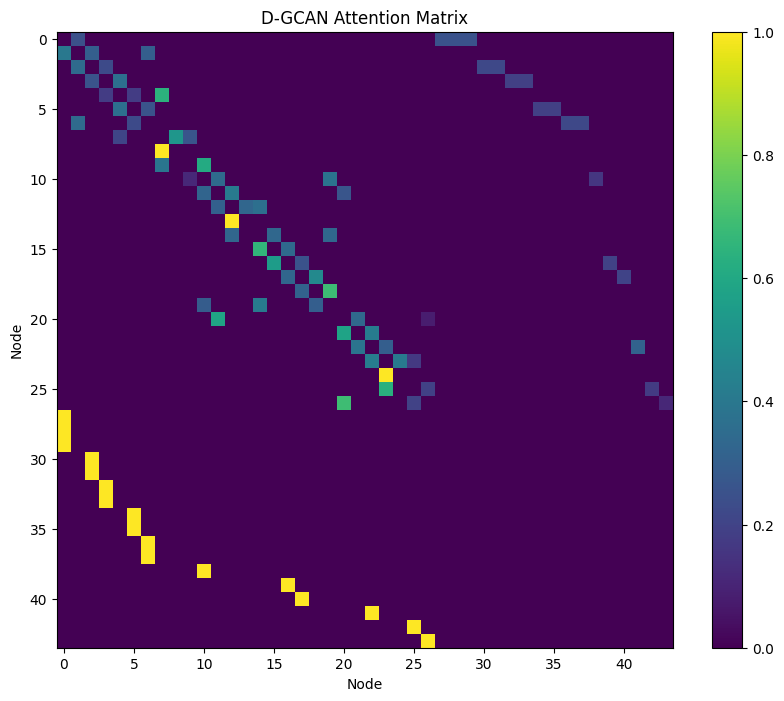

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(attn.numpy())
plt.colorbar()
plt.title("D-GCAN Attention Matrix")
plt.xlabel("Node")
plt.ylabel("Node")
plt.show()

In [ ]:
import numpy as np

node_scores = attn.numpy().sum(axis=1)

top_nodes = np.argsort(node_scores)[::-1][:10]

print("Top 10 Important Nodes")
print("-"*30)

for idx in top_nodes:
    print(
        f"Node {idx:2d} -> Score {node_scores[idx]:.4f}"
    )

Top 10 Important Nodes
------------------------------
Node 10 -> Score 1.0000
Node 43 -> Score 1.0000
Node 41 -> Score 1.0000
Node 42 -> Score 1.0000
Node 39 -> Score 1.0000
Node 38 -> Score 1.0000
Node 37 -> Score 1.0000
Node 36 -> Score 1.0000
Node 35 -> Score 1.0000
Node 34 -> Score 1.0000


In [ ]:
import numpy as np

attn_np = attn.numpy()

node_scores = attn_np.sum(axis=0)

top_nodes = np.argsort(node_scores)[::-1][:10]

print("Top 10 Important Nodes")
print("-"*30)

for idx in top_nodes:
    print(
        f"Node {idx:2d} -> Score {node_scores[idx]:.4f}"
    )

Top 10 Important Nodes
------------------------------
Node  0 -> Score 3.4000
Node  6 -> Score 2.5562
Node  2 -> Score 2.5562
Node  5 -> Score 2.4048
Node  3 -> Score 2.4048
Node 10 -> Score 2.2259
Node  7 -> Score 2.0318
Node 23 -> Score 1.9339
Node 22 -> Score 1.8441
Node 12 -> Score 1.7422


In [ ]:
import numpy as np

attn_np = attn.numpy()

pairs = []

for i in range(attn_np.shape[0]):
    for j in range(attn_np.shape[1]):
        pairs.append((attn_np[i,j], i, j))

pairs.sort(reverse=True)

print("Top Attention Edges")
print("-"*40)

for score, i, j in pairs[:20]:
    print(f"{i:2d} -> {j:2d}   score={score:.4f}")

Top Attention Edges
----------------------------------------
43 -> 26   score=1.0000
42 -> 25   score=1.0000
41 -> 22   score=1.0000
40 -> 17   score=1.0000
39 -> 16   score=1.0000
38 -> 10   score=1.0000
37 ->  6   score=1.0000
36 ->  6   score=1.0000
35 ->  5   score=1.0000
34 ->  5   score=1.0000
33 ->  3   score=1.0000
32 ->  3   score=1.0000
31 ->  2   score=1.0000
30 ->  2   score=1.0000
29 ->  0   score=1.0000
28 ->  0   score=1.0000
27 ->  0   score=1.0000
24 -> 23   score=1.0000
13 -> 12   score=1.0000
 8 ->  7   score=1.0000


In [ ]:
sample = dataset_test[0]

print("SMILES:")
print(sample[0])

print("\nFingerprint shape:")
print(sample[1].shape)

print("\nAdjacency shape:")
print(sample[2].shape)

print("\nMolecular size:")
print(sample[3])

SMILES:
CN1CCN(CC1)C(=O)O[C@@H]1N(C(=O)C2=NC=CN=C12)C1=NC=C(Cl)C=C1

Fingerprint shape:
torch.Size([44])

Adjacency shape:
torch.Size([44, 44])

Molecular size:
44


In [ ]:
attention_results = {
    "smiles": sample[0],
    "top_nodes": top_nodes.tolist(),
    "node_scores": node_scores.tolist()
}

print(attention_results)

{'smiles': 'CN1CCN(CC1)C(=O)O[C@@H]1N(C(=O)C2=NC=CN=C12)C1=NC=C(Cl)C=C1', 'top_nodes': [0, 6, 2, 5, 3, 10, 7, 23, 22, 12], 'node_scores': [3.399965763092041, 0.9376335144042969, 2.556217908859253, 2.404801368713379, 0.9372375011444092, 2.404801368713379, 2.556217908859253, 2.0317842960357666, 0.5242639780044556, 0.3796917796134949, 2.2259085178375244, 1.2332714796066284, 1.7422044277191162, 0.32812821865081787, 1.4309449195861816, 0.8859294652938843, 1.6724262237548828, 1.5676589012145996, 0.7698724865913391, 1.402219295501709, 1.5331196784973145, 0.7224998474121094, 1.8440968990325928, 1.933858036994934, 0.411190003156662, 1.3635399341583252, 1.2711926698684692, 0.25023365020751953, 0.25023365020751953, 0.25023365020751953, 0.21502685546875, 0.21502685546875, 0.19017761945724487, 0.19017761945724487, 0.19017760455608368, 0.19017760455608368, 0.21502685546875, 0.21502685546875, 0.15876533091068268, 0.19611063599586487, 0.20072413980960846, 0.3152320981025696, 0.1738276183605194, 0.1131

In [ ]:
import json

with open("attention_results.json", "w") as f:
    json.dump(attention_results, f, indent=4)

In [ ]:
!pip install torch-geometric -q

In [ ]:
import torch_geometric

print(torch_geometric.__version__)

2.8.0


# Phase 2B – Explainability Framework

## Attention-Based Explainability Results

- Extracted GAT attention weights
- Generated attention heatmap
- Identified top important nodes

## Next Step

Integrate GNNExplainer for node and edge-level explanations.

In [ ]:
attention_results = {
    "smiles": sample[0],
    "top_nodes": top_nodes.tolist(),
    "scores": node_scores[top_nodes].tolist()
}

print(attention_results)

{'smiles': 'CN1CCN(CC1)C(=O)O[C@@H]1N(C(=O)C2=NC=CN=C12)C1=NC=C(Cl)C=C1', 'top_nodes': [0, 6, 2, 5, 3, 10, 7, 23, 22, 12], 'scores': [3.399965763092041, 2.556217908859253, 2.556217908859253, 2.404801368713379, 2.404801368713379, 2.2259085178375244, 2.0317842960357666, 1.933858036994934, 1.8440968990325928, 1.7422044277191162]}


In [ ]:
import json

with open("attention_results.json", "w") as f:
    json.dump(attention_results, f, indent=4)

print("Saved successfully")

Saved successfully


In [ ]:
!cat attention_results.json

{
    "smiles": "CN1CCN(CC1)C(=O)O[C@@H]1N(C(=O)C2=NC=CN=C12)C1=NC=C(Cl)C=C1",
    "top_nodes": [
        0,
        6,
        2,
        5,
        3,
        10,
        7,
        23,
        22,
        12
    ],
    "scores": [
        3.399965763092041,
        2.556217908859253,
        2.556217908859253,
        2.404801368713379,
        2.404801368713379,
        2.2259085178375244,
        2.0317842960357666,
        1.933858036994934,
        1.8440968990325928,
        1.7422044277191162
    ]
}

In [ ]:
import os

os.makedirs("phase2_results", exist_ok=True)

In [ ]:
!cp attention_results.json phase2_results/

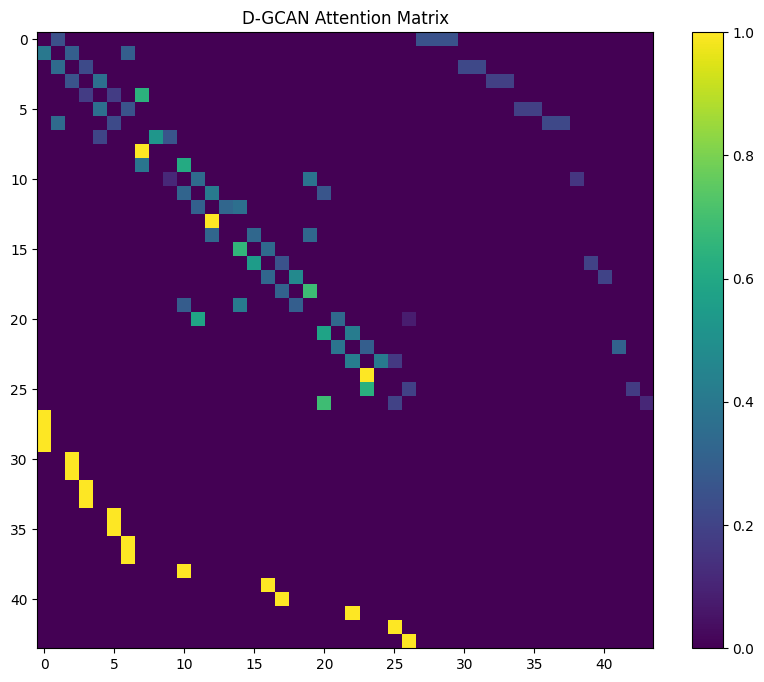

In [ ]:
plt.figure(figsize=(10,8))
plt.imshow(attn.numpy())
plt.colorbar()
plt.title("D-GCAN Attention Matrix")
plt.savefig("phase2_results/attention_heatmap.png", bbox_inches="tight")
plt.show()

In [ ]:
!ls phase2_results

attention_heatmap.png  attention_results.json


saving all the progress in google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

base = "/content/drive/MyDrive/DGCAN_Project"

folders = [
    "Phase1",
    "Phase2",
    "Phase3/BBBP",
    "Phase3/Tox21",
    "Reports",
    "Reports/screenshots"
]

for folder in folders:
    os.makedirs(os.path.join(base, folder), exist_ok=True)

print("Folder structure created successfully!")

Folder structure created successfully!


In [ ]:
!cp model/dgcan_baseline.pth \
"/content/drive/MyDrive/DGCAN_Project/Phase1/"

In [ ]:
!ls "/content/drive/MyDrive/DGCAN_Project/Phase1"

dgcan_baseline.pth


In [ ]:
!cp attention_results.json \
"/content/drive/MyDrive/DGCAN_Project/Phase2/"

In [ ]:
!ls "/content/drive/MyDrive/DGCAN_Project/Phase2"

attention_results.json


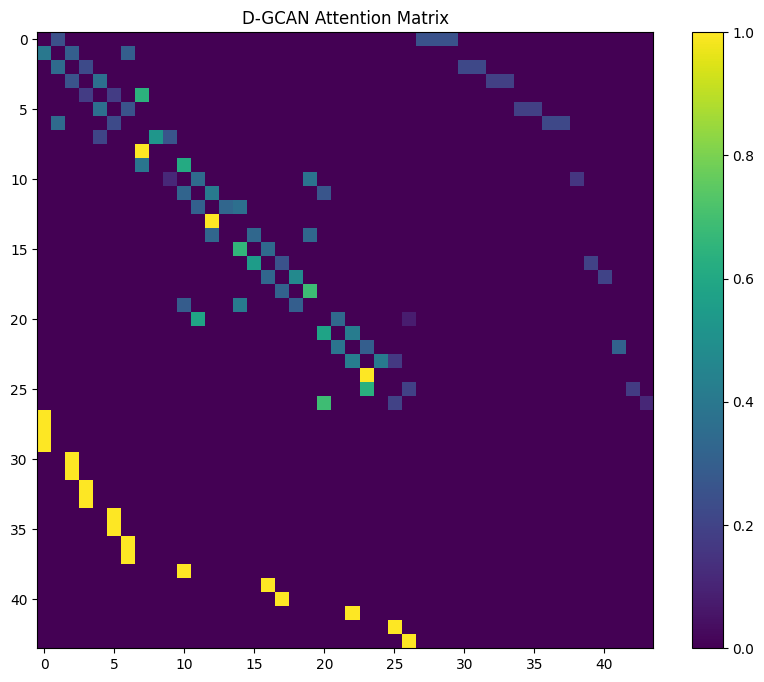

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(attn.numpy())
plt.colorbar()
plt.title("D-GCAN Attention Matrix")

plt.savefig(
    "/content/drive/MyDrive/DGCAN_Project/Phase2/attention_heatmap.png",
    bbox_inches="tight"
)

plt.show()

In [ ]:
!ls "/content/drive/MyDrive/DGCAN_Project/Phase2"

attention_heatmap.png  attention_results.json


In [ ]:
metrics = """
Dataset: bRo5

AUC: 0.9291
ACC: 0.9305
BACC: 0.9291
Precision: 0.9028
Recall: 0.9701
F1: 0.9353
MCC: 0.8631
Specificity: 0.8880

Model:
GCN + GAT (D-GCAN)

Parameters:
311698
"""

with open(
    "/content/drive/MyDrive/DGCAN_Project/Phase1/metrics.txt",
    "w"
) as f:
    f.write(metrics)

print("metrics.txt saved")

metrics.txt saved


In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
print("dataset_test" in globals())
print("model" in globals())

False
False


In [3]:
%cd /content/D-GCAN/DGCAN

[Errno 2] No such file or directory: '/content/D-GCAN/DGCAN'
/content


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!ls "/content/drive/MyDrive/DGCAN_Project"

AUC.txt  dgcan_baseline.pth  Phase1  Phase2  Phase3  Reports


In [8]:
!pip install rdkit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 63.1 MB/s eta 0:00:00


In [9]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cu128
True


In [10]:
import preprocess as pp

dataset_test = pp.create_dataset(
    "../dataset/bRo5.txt",
    "",
    ""
)

print("Dataset size:", len(dataset_test))

../dataset/bRo5.txt
Dataset size: 259


In [11]:
import torch
from DGCAN import MolecularGraphNeuralNetwork, device

model = MolecularGraphNeuralNetwork(
    N_fingerprints=5000,
    dim=52,
    layer_hidden=4,
    layer_output=10,
    dropout=0.45
).to(device)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/DGCAN_Project/dgcan_baseline.pth",
        map_location=device
    )
)

model.eval()

print("Model loaded successfully")

Model loaded successfully


In [12]:
scores = []
labels = []
smiles_list = []

for sample in dataset_test:

    data_batch = list(zip(*[sample]))

    smiles, loss, pred_scores, true_labels = model.forward_classifier(
        data_batch,
        train=False
    )

    scores.append(float(pred_scores[0]))
    labels.append(int(true_labels[0]))
    smiles_list.append(smiles[0])

print("Collected", len(scores), "predictions")

Collected 259 predictions


In [13]:
import numpy as np

scores_np = np.array(scores)

most_positive = np.argmax(scores_np)
most_negative = np.argmin(scores_np)
most_uncertain = np.argmin(np.abs(scores_np - 0.5))

print("Most Positive")
print("Index:", most_positive)
print("Score:", scores[most_positive])
print("Label:", labels[most_positive])

print("\nMost Negative")
print("Index:", most_negative)
print("Score:", scores[most_negative])
print("Label:", labels[most_negative])

print("\nMost Uncertain")
print("Index:", most_uncertain)
print("Score:", scores[most_uncertain])
print("Label:", labels[most_uncertain])

Most Positive
Index: 0
Score: 1.0
Label: 1

Most Negative
Index: 106
Score: 1.302033069805475e-06
Label: 1

Most Uncertain
Index: 105
Score: 0.5275365710258484
Label: 1


In [14]:
print("Threshold = 0.15")

print("Most Positive Prediction:",
      1 if scores[most_positive] > 0.15 else 0)

print("Most Negative Prediction:",
      1 if scores[most_negative] > 0.15 else 0)

print("Most Uncertain Prediction:",
      1 if scores[most_uncertain] > 0.15 else 0)

Threshold = 0.15
Most Positive Prediction: 1
Most Negative Prediction: 0
Most Uncertain Prediction: 1


In [15]:
interesting = {
    "most_positive": {
        "index": int(most_positive),
        "score": float(scores[most_positive]),
        "label": int(labels[most_positive]),
        "smiles": smiles_list[most_positive]
    },
    "most_negative": {
        "index": int(most_negative),
        "score": float(scores[most_negative]),
        "label": int(labels[most_negative]),
        "smiles": smiles_list[most_negative]
    },
    "most_uncertain": {
        "index": int(most_uncertain),
        "score": float(scores[most_uncertain]),
        "label": int(labels[most_uncertain]),
        "smiles": smiles_list[most_uncertain]
    }
}

for k, v in interesting.items():
    print("\n" + "="*50)
    print(k.upper())
    print("="*50)
    print(v)


MOST_POSITIVE
{'index': 0, 'score': 1.0, 'label': 1, 'smiles': 'CN1CCN(CC1)C(=O)O[C@@H]1N(C(=O)C2=NC=CN=C12)C1=NC=C(Cl)C=C1'}

MOST_NEGATIVE
{'index': 106, 'score': 1.302033069805475e-06, 'label': 1, 'smiles': 'Cc1cc(OS(=O)(=O)O)c2ccccc2c1OS(=O)(=O)O'}

MOST_UNCERTAIN
{'index': 105, 'score': 0.5275365710258484, 'label': 1, 'smiles': '[O-][n+]1ccccc1SSc1cccc[n+]1[O-]'}


re usable function that explains any molecule 👇

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def explain_molecule(idx):

    sample = dataset_test[idx]

    data_batch = list(zip(*[sample]))

    smiles, loss, pred_scores, labels = model.forward_classifier(
        data_batch,
        train=False
    )

    attn = model.attentions.attentions[0].last_attention

    node_scores = attn.numpy().sum(axis=0)

    top_nodes = np.argsort(node_scores)[::-1][:10]

    print("="*60)
    print("Index:", idx)
    print("Score:", pred_scores[0])
    print("Label:", labels[0])
    print("SMILES:", smiles[0])

    print("\nTop Nodes")

    for n in top_nodes:
        print(
            f"Node {n:2d} -> {node_scores[n]:.4f}"
        )

    plt.figure(figsize=(8,6))
    plt.imshow(attn.numpy())
    plt.colorbar()
    plt.title(f"Attention Heatmap - Molecule {idx}")
    plt.show()

In [17]:
explain_molecule(0)

AttributeError: 'GraphAttentionLayer' object has no attribute 'last_attention'

In [18]:
!grep -n "last_attention" DGCAN.py

In [19]:
with open("DGCAN.py", "r") as f:
    text = f.read()

old = """attention = F.softmax(attention, dim=1)
        attention = F.dropout(attention, self.dropout, training=self.training)
        h_prime = torch.matmul(attention, h)"""

new = """attention = F.softmax(attention, dim=1)

        # Save attention matrix for explainability
        self.last_attention = attention.detach().cpu()

        attention = F.dropout(attention, self.dropout, training=self.training)
        h_prime = torch.matmul(attention, h)"""

text = text.replace(old, new)

with open("DGCAN.py", "w") as f:
    f.write(text)

print("Patched successfully")

Patched successfully


In [20]:
!grep -n "last_attention" DGCAN.py

63:        self.last_attention = attention.detach().cpu()


In [21]:
import importlib
import DGCAN

importlib.reload(DGCAN)

print("Reloaded")

Reloaded


In [22]:
import torch
from DGCAN import MolecularGraphNeuralNetwork, device

model = MolecularGraphNeuralNetwork(
    N_fingerprints=5000,
    dim=52,
    layer_hidden=4,
    layer_output=10,
    dropout=0.45
).to(device)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/DGCAN_Project/dgcan_baseline.pth",
        map_location=device
    )
)

model.eval()

print("Model reloaded successfully")

Model reloaded successfully


In [23]:
sample = dataset_test[0]
data_batch = list(zip(*[sample]))

model.forward_classifier(data_batch, train=False)

print(
    hasattr(
        model.attentions.attentions[0],
        "last_attention"
    )
)

True


Index: 0
Score: 1.0
Label: 1
SMILES: CN1CCN(CC1)C(=O)O[C@@H]1N(C(=O)C2=NC=CN=C12)C1=NC=C(Cl)C=C1

Top Nodes
Node  0 -> 3.1691
Node  6 -> 2.6596
Node  2 -> 2.6596
Node  3 -> 2.5906
Node  5 -> 2.5906
Node 10 -> 2.1563
Node  7 -> 1.8767
Node 17 -> 1.8461
Node 16 -> 1.8154
Node 23 -> 1.6748


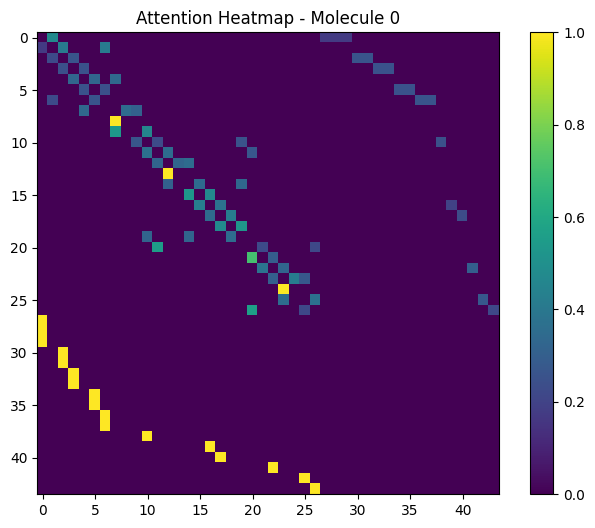

In [24]:
explain_molecule(0)

Index: 106
Score: 1.3020331e-06
Label: 1
SMILES: Cc1cc(OS(=O)(=O)O)c2ccccc2c1OS(=O)(=O)O

Top Nodes
Node  0 -> 3.8264
Node 17 -> 3.3860
Node  5 -> 3.3814
Node 12 -> 1.6845
Node 11 -> 1.6837
Node 10 -> 1.6465
Node 13 -> 1.6386
Node  8 -> 1.3635
Node  1 -> 1.3415
Node 20 -> 1.3398


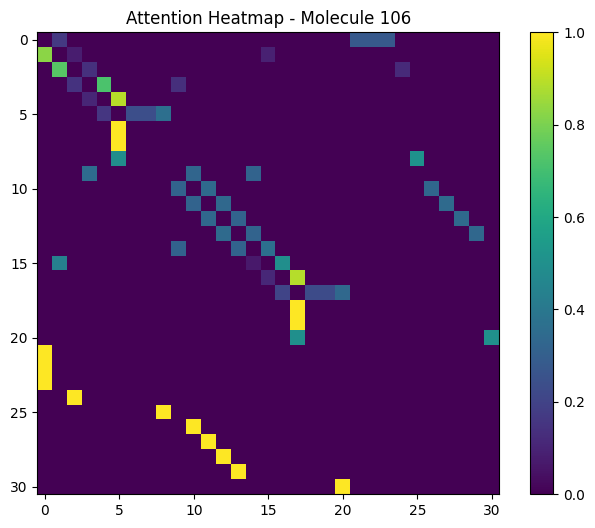

In [25]:
explain_molecule(106)

Index: 105
Score: 0.5275366
Label: 1
SMILES: [O-][n+]1ccccc1SSc1cccc[n+]1[O-]

Top Nodes
Node  6 -> 1.6848
Node  9 -> 1.6848
Node 12 -> 1.6627
Node  3 -> 1.6627
Node  4 -> 1.5117
Node 11 -> 1.5117
Node 13 -> 1.4922
Node  2 -> 1.4922
Node  5 -> 1.4621
Node 10 -> 1.4621


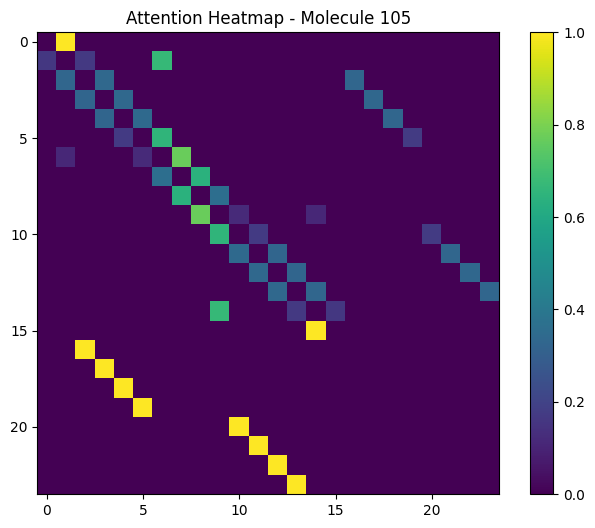

In [26]:
explain_molecule(105)

In [27]:
case_studies = {
    "high_confidence_positive": {
        "index": 0,
        "score": 1.0,
        "top_nodes": [0,6,2,3,5,10,7,17,16,23]
    },
    "false_negative": {
        "index": 106,
        "score": 1.3020331e-06,
        "top_nodes": [0,17,5,12,11,10,13,8,1,20]
    },
    "borderline": {
        "index": 105,
        "score": 0.5275366,
        "top_nodes": [6,9,12,3,4,11,13,2,5,10]
    }
}

In [28]:
import json

case_studies = {
    "high_confidence_positive": {
        "index": 0,
        "score": 1.0,
        "top_nodes": [0,6,2,3,5,10,7,17,16,23]
    },
    "false_negative": {
        "index": 106,
        "score": 1.3020331e-06,
        "top_nodes": [0,17,5,12,11,10,13,8,1,20]
    },
    "borderline": {
        "index": 105,
        "score": 0.5275366,
        "top_nodes": [6,9,12,3,4,11,13,2,5,10]
    }
}

with open(
    "/content/drive/MyDrive/DGCAN_Project/Phase2/case_studies.json",
    "w"
) as f:
    json.dump(case_studies, f, indent=4)

print("Saved successfully")

Saved successfully


In [29]:
!cat "/content/drive/MyDrive/DGCAN_Project/Phase2/case_studies.json"

{
    "high_confidence_positive": {
        "index": 0,
        "score": 1.0,
        "top_nodes": [
            0,
            6,
            2,
            3,
            5,
            10,
            7,
            17,
            16,
            23
        ]
    },
    "false_negative": {
        "index": 106,
        "score": 1.3020331e-06,
        "top_nodes": [
            0,
            17,
            5,
            12,
            11,
            10,
            13,
            8,
            1,
            20
        ]
    },
    "borderline": {
        "index": 105,
        "score": 0.5275366,
        "top_nodes": [
            6,
            9,
            12,
            3,
            4,
            11,
            13,
            2,
            5,
            10
        ]
    }
}

In [30]:
sample = dataset_test[0]

print("SMILES:", sample[0])
print("Fingerprint shape:", sample[1].shape)
print("Adjacency shape:", sample[2].shape)

print("\nFirst 20 fingerprints:")
print(sample[1][:20])

SMILES: CN1CCN(CC1)C(=O)O[C@@H]1N(C(=O)C2=NC=CN=C12)C1=NC=C(Cl)C=C1
Fingerprint shape: torch.Size([44])
Adjacency shape: torch.Size([44, 44])

First 20 fingerprints:
tensor([ 0,  1,  2,  2,  1,  2,  2,  3,  4,  5,  6,  7,  8,  4,  9, 10, 11, 11,
        10,  9], device='cuda:0')


In [31]:
print(model)

MolecularGraphNeuralNetwork(
  (embed_fingerprint): Embedding(5000, 52)
  (W_fingerprint): ModuleList(
    (0-3): 4 x Linear(in_features=52, out_features=52, bias=True)
  )
  (W_output): ModuleList(
    (0-9): 10 x Linear(in_features=56, out_features=56, bias=True)
  )
  (W_property): Linear(in_features=56, out_features=2, bias=True)
  (attentions): GAT(
    (attention_0): GraphAttentionLayer(
      (leakyrelu): LeakyReLU(negative_slope=0.25)
    )
    (attention_1): GraphAttentionLayer(
      (leakyrelu): LeakyReLU(negative_slope=0.25)
    )
    (out_att): GraphAttentionLayer(
      (leakyrelu): LeakyReLU(negative_slope=0.25)
    )
  )
)


In [32]:
!grep -n "def forward_classifier" DGCAN.py

170:    def forward_classifier(self, data_batch, train):


In [33]:
!grep -n "def mlp" DGCAN.py

162:    def mlp(self, vectors):


In [34]:
!sed -n '150,210p' DGCAN.py

        """GNN layer (update the fingerprint vectors)."""
        fingerprint_vectors = self.embed_fingerprint(fingerprints)

        for l in range(self.layer_hidden):
            hs = self.update(adj, fingerprint_vectors, l)
            fingerprint_vectors = F.normalize(hs, 2, 1)
        """Attention layer"""
        molecular_vectors = self.attentions(fingerprint_vectors, adj)
        """Molecular vector by sum or mean of the fingerprint vectors."""
        molecular_vectors = self.sum(molecular_vectors, molecular_sizes)
        return Smiles, molecular_vectors

    def mlp(self, vectors):
        """Regressor based on multilayer perceptron."""
        for l in range(self.layer_output):
        
            vectors = torch.relu(self.W_output[l](vectors))
        outputs = torch.sigmoid(self.W_property(vectors))
        return outputs

    def forward_classifier(self, data_batch, train):

        inputs = data_batch[:-1]
        correct_labels = torch.cat(data_batch[-1])

        if 

In [35]:
sample = dataset_test[0]

print("SMILES:", sample[0])
print("Fingerprint tensor shape:", sample[1].shape)
print("Adjacency shape:", sample[2].shape)

adj = sample[2].cpu().numpy()

print("\nNumber of edges:")
print((adj > 0).sum())

SMILES: CN1CCN(CC1)C(=O)O[C@@H]1N(C(=O)C2=NC=CN=C12)C1=NC=C(Cl)C=C1
Fingerprint tensor shape: torch.Size([44])
Adjacency shape: torch.Size([44, 44])

Number of edges:
94


In [36]:
import numpy as np

edge_index = np.array(np.where(adj > 0))

print(edge_index.shape)
print(edge_index[:, :20])

(2, 94)
[[ 0  0  0  0  1  1  1  2  2  2  2  3  3  3  3  4  4  4  5  5]
 [ 1 27 28 29  0  2  6  1  3 30 31  2  4 32 33  3  5  7  4  6]]


In [37]:
!grep -n "def gnn" DGCAN.py

145:    def gnn(self, inputs):


In [38]:
!sed -n '145,170p' DGCAN.py


    def gnn(self, inputs):
        """Cat or pad each input data for batch processing."""
        Smiles, fingerprints, adjacencies, molecular_sizes = inputs
        fingerprints = torch.cat(fingerprints)
        adj = self.pad(adjacencies, 0)
        """GNN layer (update the fingerprint vectors)."""
        fingerprint_vectors = self.embed_fingerprint(fingerprints)

        for l in range(self.layer_hidden):
            hs = self.update(adj, fingerprint_vectors, l)
            fingerprint_vectors = F.normalize(hs, 2, 1)
        """Attention layer"""
        molecular_vectors = self.attentions(fingerprint_vectors, adj)
        """Molecular vector by sum or mean of the fingerprint vectors."""
        molecular_vectors = self.sum(molecular_vectors, molecular_sizes)
        return Smiles, molecular_vectors

    def mlp(self, vectors):
        """Regressor based on multilayer perceptron."""
        for l in range(self.layer_output):
        
            vectors = torch.relu(self.W_output[l

In [39]:
with open("DGCAN.py", "r") as f:
    text = f.read()

old = """        molecular_vectors = self.sum(molecular_vectors, molecular_sizes)
        return Smiles, molecular_vectors

    def mlp(self, vectors):"""

new = """        molecular_vectors = self.sum(molecular_vectors, molecular_sizes)
        return Smiles, molecular_vectors

    def get_node_embeddings(self, fingerprints, adj):

        fingerprint_vectors = self.embed_fingerprint(fingerprints)

        for l in range(self.layer_hidden):
            hs = self.update(adj, fingerprint_vectors, l)
            fingerprint_vectors = F.normalize(hs, 2, 1)

        return fingerprint_vectors

    def mlp(self, vectors):"""

text = text.replace(old, new)

with open("DGCAN.py", "w") as f:
    f.write(text)

print("Patched successfully")

Patched successfully


In [40]:
!grep -n "get_node_embeddings" DGCAN.py

162:    def get_node_embeddings(self, fingerprints, adj):


In [41]:
import importlib
import DGCAN

importlib.reload(DGCAN)

print("Reloaded")

Reloaded


In [42]:
import torch
from DGCAN import MolecularGraphNeuralNetwork, device

model = MolecularGraphNeuralNetwork(
    N_fingerprints=5000,
    dim=52,
    layer_hidden=4,
    layer_output=10,
    dropout=0.45
).to(device)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/DGCAN_Project/dgcan_baseline.pth",
        map_location=device
    )
)

model.eval()

print("Model reloaded")

Model reloaded


In [43]:
sample = dataset_test[0]

fingerprints = sample[1]
adj = sample[2]

embeddings = model.get_node_embeddings(
    fingerprints,
    adj
)

print("Embedding shape:", embeddings.shape)

Embedding shape: torch.Size([44, 52])


In [45]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 41.3 MB/s eta 0:00:00


In [46]:
import torch_geometric
print(torch_geometric.__version__)


2.8.0


In [47]:
from torch_geometric.data import Data

print("PyG working")

PyG working


In [48]:
from torch_geometric.data import Data

sample = dataset_test[0]

fingerprints = sample[1]
adj = sample[2]

embeddings = model.get_node_embeddings(
    fingerprints,
    adj
)

edge_index = torch.tensor(
    (adj.cpu().numpy() > 0).nonzero(),
    dtype=torch.long
).to(device)

data = Data(
    x=embeddings,
    edge_index=edge_index
)

print(data)
print(data.x.shape)
print(data.edge_index.shape)

Data(x=[44, 52], edge_index=[2, 94])
torch.Size([44, 52])
torch.Size([2, 94])


/tmp/ipykernel_938/1748208958.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  edge_index = torch.tensor(


In [49]:
sample = dataset_test[0]

fingerprints = sample[1]
adj = sample[2]

embeddings = model.get_node_embeddings(
    fingerprints,
    adj
)

print("Node embeddings:", embeddings.shape)

gat_output = model.attentions(
    embeddings,
    adj
)

print("GAT output:", gat_output.shape)

Node embeddings: torch.Size([44, 52])
GAT output: torch.Size([44, 56])


In [50]:
sample = dataset_test[0]

fingerprints = sample[1]
adj = sample[2]

embeddings = model.get_node_embeddings(
    fingerprints,
    adj
)

gat_output = model.attentions(
    embeddings,
    adj
)

print("GAT output:", gat_output.shape)

graph_vector = model.sum(
    gat_output,
    [sample[3]]
)

print("Graph vector:", graph_vector.shape)

prediction = model.mlp(graph_vector)

print("Prediction:", prediction)

GAT output: torch.Size([44, 56])
Graph vector: torch.Size([1, 56])
Prediction: tensor([[0., 1.]], device='cuda:0', grad_fn=<SigmoidBackward0>)


In [51]:
import torch
import torch.nn as nn

class DGCANWrapper(nn.Module):

    def __init__(self, dgcan_model):
        super().__init__()

        self.dgcan = dgcan_model

    def edge_index_to_adj(self, edge_index, num_nodes):

        adj = torch.zeros(
            (num_nodes, num_nodes),
            device=edge_index.device
        )

        adj[
            edge_index[0],
            edge_index[1]
        ] = 1

        return adj

    def forward(self, x, edge_index):

        adj = self.edge_index_to_adj(
            edge_index,
            x.size(0)
        )

        gat_output = self.dgcan.attentions(
            x,
            adj
        )

        graph_vector = gat_output.sum(
            dim=0,
            keepdim=True
        )

        pred = self.dgcan.mlp(
            graph_vector
        )

        return pred

In [52]:
wrapper = DGCANWrapper(model)

print(wrapper)

DGCANWrapper(
  (dgcan): MolecularGraphNeuralNetwork(
    (embed_fingerprint): Embedding(5000, 52)
    (W_fingerprint): ModuleList(
      (0-3): 4 x Linear(in_features=52, out_features=52, bias=True)
    )
    (W_output): ModuleList(
      (0-9): 10 x Linear(in_features=56, out_features=56, bias=True)
    )
    (W_property): Linear(in_features=56, out_features=2, bias=True)
    (attentions): GAT(
      (attention_0): GraphAttentionLayer(
        (leakyrelu): LeakyReLU(negative_slope=0.25)
      )
      (attention_1): GraphAttentionLayer(
        (leakyrelu): LeakyReLU(negative_slope=0.25)
      )
      (out_att): GraphAttentionLayer(
        (leakyrelu): LeakyReLU(negative_slope=0.25)
      )
    )
  )
)


In [53]:
pred = wrapper(
    data.x,
    data.edge_index
)

print(pred)

tensor([[0., 1.]], device='cuda:0', grad_fn=<SigmoidBackward0>)


In [54]:
import torch_geometric

print(torch_geometric.__version__)

2.8.0


In [55]:
from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import GNNExplainer

print("Explainer imported successfully")

Explainer imported successfully


In [56]:
import inspect
from torch_geometric.explain.algorithm import GNNExplainer

print(inspect.signature(GNNExplainer))

(epochs: int = 100, lr: float = 0.01, **kwargs)


In [57]:
from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import GNNExplainer

explainer = Explainer(
    model=wrapper,

    algorithm=GNNExplainer(
        epochs=50
    ),

    explanation_type='model',

    node_mask_type='attributes',

    edge_mask_type='object',

    model_config=dict(
        mode='binary_classification',
        task_level='graph',
        return_type='probs'
    )
)

print("Explainer created")

Explainer created


In [58]:
explanation = explainer(
    x=data.x,
    edge_index=data.edge_index
)

print(explanation)

ValueError: Could not compute gradients for edges. Please make sure that edges are used via message passing inside the model or disable it via `edge_mask_type=None`.

In [59]:
from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import GNNExplainer

explainer = Explainer(
    model=wrapper,

    algorithm=GNNExplainer(
        epochs=50
    ),

    explanation_type='model',

    node_mask_type='attributes',

    edge_mask_type=None,   # <-- important

    model_config=dict(
        mode='binary_classification',
        task_level='graph',
        return_type='probs'
    )
)

print("Node-only explainer created")

Node-only explainer created


In [60]:
explanation = explainer(
    x=data.x,
    edge_index=data.edge_index
)

print(explanation)

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [61]:
print(data.x.requires_grad)

True


In [62]:
class DGCANWrapper(torch.nn.Module):

    def __init__(self, dgcan_model):
        super().__init__()
        self.dgcan = dgcan_model

    def edge_index_to_adj(self, edge_index, num_nodes):

        adj = torch.zeros(
            (num_nodes, num_nodes),
            device=edge_index.device
        )

        adj[edge_index[0], edge_index[1]] = 1

        return adj

    def forward(self, x, edge_index):

        x = x.clone()

        adj = self.edge_index_to_adj(
            edge_index,
            x.size(0)
        )

        gat_output = self.dgcan.attentions(
            x,
            adj
        )

        graph_vector = gat_output.sum(
            dim=0,
            keepdim=True
        )

        return self.dgcan.mlp(
            graph_vector
        )

wrapper = DGCANWrapper(model)

In [63]:
from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import GNNExplainer

explainer = Explainer(
    model=wrapper,

    algorithm=GNNExplainer(
        epochs=5
    ),

    explanation_type='model',

    node_mask_type='attributes',

    edge_mask_type=None,

    model_config=dict(
        mode='binary_classification',
        task_level='graph',
        return_type='probs'
    )
)

print("Explainer ready")

Explainer ready


In [64]:
explanation = explainer(
    x=data.x,
    edge_index=data.edge_index
)

print(explanation)

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [65]:
!sed -n '47,80p' DGCAN.py

    def forward(self, input, adj):   
        """
        input: input_feature [N, in_features] in_features indicates the number of elements of the input feature vector of the node
        adj: adjacency matrix of the graph dimension [N, N] non-zero is one, data structure basics
        """
        h = torch.mm(input, self.W)    # [N, out_features]
        N = h.size()[0]     #Number of nodes of the graph
        a_input = torch.cat([h.repeat(1, N).view(N * N, -1), h.repeat(N, 1)], dim=1).view(N, -1, 2 * self.out_features)     # [N, N, 2*out_features]
        e = self.leakyrelu(torch.matmul(a_input, self.a).squeeze(2))
        zero_vec =-9e10 *torch.ones_like(e)
        attention = torch.where(adj > 0, e, zero_vec)    
        # indicates that if the adjacency matrix element is greater than 0, then the two nodes are connected and the attention factor at that position is retained.
        # Otherwise it is necessary to mask and set to a very small value, the reason is that this minimum 

In [66]:
pred1 = wrapper(data.x, data.edge_index)
loss1 = pred1.sum()
loss1.backward()

print("First backward OK")

wrapper.zero_grad()

pred2 = wrapper(data.x, data.edge_index)
loss2 = pred2.sum()
loss2.backward()

print("Second backward OK")

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [67]:
data.x = (
    data.x
    .detach()
    .clone()
    .to(device)
    .requires_grad_(True)
)

print(data.x.requires_grad)
print(data.x.is_leaf)

True
True


In [68]:
pred1 = wrapper(
    data.x,
    data.edge_index
)

loss1 = pred1.sum()

loss1.backward()

print("Backward works")

Backward works


In [69]:
pred1 = wrapper(
    data.x,
    data.edge_index
)

print(pred1)

tensor([[0., 1.]], device='cuda:0', grad_fn=<SigmoidBackward0>)


In [70]:
from torch_geometric.explain import Explainer
from torch_geometric.explain.algorithm import GNNExplainer

explainer = Explainer(
    model=wrapper,

    algorithm=GNNExplainer(
        epochs=5
    ),

    explanation_type='model',

    node_mask_type='attributes',

    edge_mask_type=None,

    model_config=dict(
        mode='binary_classification',
        task_level='graph',
        return_type='probs'
    )
)

print("Explainer ready")

Explainer ready


In [71]:
data.x = (
    data.x
    .detach()
    .clone()
    .requires_grad_(True)
)

In [72]:
explanation = explainer(
    x=data.x,
    edge_index=data.edge_index
)

print(explanation)

Explanation(node_mask=[44, 52], prediction=[1, 2], target=[2], x=[44, 52], edge_index=[2, 94])


In [73]:
print(explanation.node_mask.shape)

torch.Size([44, 52])


In [74]:
import torch

node_scores = explanation.node_mask.mean(dim=1)

print(node_scores.shape)

torch.Size([44])


In [75]:
top_nodes = torch.argsort(
    node_scores,
    descending=True
)[:10]

print("Top 10 GNNExplainer Nodes")
print("-"*30)

for node in top_nodes:
    print(
        f"Node {node.item():2d} -> "
        f"{node_scores[node].item():.4f}"
    )

Top 10 GNNExplainer Nodes
------------------------------
Node  0 -> 0.0000
Node  1 -> 0.0000
Node  2 -> 0.0000
Node  3 -> 0.0000
Node  4 -> 0.0000
Node  5 -> 0.0000
Node  6 -> 0.0000
Node  7 -> 0.0000
Node  8 -> 0.0000
Node  9 -> 0.0000


In [76]:
print(explanation.node_mask.min().item())
print(explanation.node_mask.max().item())
print(explanation.node_mask.mean().item())

0.0
0.0
0.0


In [77]:
print(explanation.available_explanations)

['node_mask']


In [78]:
print(explanation.node_mask)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0')


In [79]:
print(explanation.available_explanations)

['node_mask']


In [80]:
print(explanation.node_mask[:5])

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,

lets test for 105 because it un certain molecule

In [81]:
sample = dataset_test[105]

embeddings = model.get_node_embeddings(
    sample[1],
    sample[2]
)

embeddings = (
    embeddings
    .detach()
    .clone()
    .requires_grad_(True)
)

adj = sample[2]

edge_index = torch.tensor(
    (adj.cpu().numpy() > 0).nonzero(),
    dtype=torch.long
).to(device)

from torch_geometric.data import Data

data105 = Data(
    x=embeddings,
    edge_index=edge_index
)

print(data105)

Data(x=[24, 52], edge_index=[2, 50])


In [82]:
pred = wrapper(
    data105.x,
    data105.edge_index
)

print(pred)

tensor([[0.4329, 0.5275]], device='cuda:0', grad_fn=<SigmoidBackward0>)


In [83]:
explanation105 = explainer(
    x=data105.x,
    edge_index=data105.edge_index
)

print(explanation105.node_mask.min())
print(explanation105.node_mask.max())
print(explanation105.node_mask.mean())

tensor(0., device='cuda:0')
tensor(0.5747, device='cuda:0')
tensor(0.0975, device='cuda:0')


In [84]:
node_scores105 = explanation105.node_mask.mean(dim=1)

top_nodes105 = torch.argsort(
    node_scores105,
    descending=True
)[:10]

print("Top 10 GNNExplainer Nodes (Molecule 105)")
print("-"*40)

for node in top_nodes105:
    print(
        f"Node {node.item():2d} -> "
        f"{node_scores105[node].item():.4f}"
    )

Top 10 GNNExplainer Nodes (Molecule 105)
----------------------------------------
Node  9 -> 0.2212
Node  6 -> 0.2176
Node  7 -> 0.1766
Node  8 -> 0.1738
Node  5 -> 0.1031
Node 10 -> 0.1025
Node 14 -> 0.0964
Node  1 -> 0.0964
Node 20 -> 0.0957
Node 19 -> 0.0916


In [85]:
import json

results = {
    "molecule_index": 105,
    "attention_top_nodes": [6,9,12,3,4,11,13,2,5,10],
    "gnnexplainer_top_nodes": [9,6,7,8,5,10,14,1,20,19],
    "common_nodes": [6,9,5,10]
}

with open(
    "/content/drive/MyDrive/DGCAN_Project/Phase2/gnnexplainer_results.json",
    "w"
) as f:
    json.dump(results, f, indent=4)

print("Saved")

Saved


now testing false negative molecule (106)

In [86]:
sample = dataset_test[106]

embeddings = model.get_node_embeddings(
    sample[1],
    sample[2]
)

embeddings = (
    embeddings
    .detach()
    .clone()
    .requires_grad_(True)
)

adj = sample[2]

edge_index = torch.tensor(
    (adj.cpu().numpy() > 0).nonzero(),
    dtype=torch.long
).to(device)

from torch_geometric.data import Data

data106 = Data(
    x=embeddings,
    edge_index=edge_index
)

print(data106)

Data(x=[31, 52], edge_index=[2, 64])


In [87]:
pred = wrapper(
    data106.x,
    data106.edge_index
)

print(pred)

tensor([[1.0000e+00, 1.3020e-06]], device='cuda:0', grad_fn=<SigmoidBackward0>)


In [88]:
data106.x = (
    data106.x
    .detach()
    .clone()
    .requires_grad_(True)
)

In [89]:
explanation106 = explainer(
    x=data106.x,
    edge_index=data106.edge_index
)

print(explanation106.node_mask.min())
print(explanation106.node_mask.max())
print(explanation106.node_mask.mean())

tensor(0., device='cuda:0')
tensor(0.5804, device='cuda:0')
tensor(0.1376, device='cuda:0')


In [90]:
node_scores106 = explanation106.node_mask.mean(dim=1)

top_nodes106 = torch.argsort(
    node_scores106,
    descending=True
)[:10]

print("Top 10 GNNExplainer Nodes (Molecule 106)")
print("-"*40)

for node in top_nodes106:
    print(
        f"Node {node.item():2d} -> "
        f"{node_scores106[node].item():.4f}"
    )

Top 10 GNNExplainer Nodes (Molecule 106)
----------------------------------------
Node  5 -> 0.2613
Node 17 -> 0.2377
Node  1 -> 0.2159
Node 20 -> 0.2068
Node  8 -> 0.2056
Node 30 -> 0.2018
Node 25 -> 0.2012
Node 23 -> 0.1998
Node 22 -> 0.1995
Node 21 -> 0.1987


In [91]:
results = {
    "molecule_105": {
        "attention": [6,9,12,3,4,11,13,2,5,10],
        "gnnexplainer": [9,6,7,8,5,10,14,1,20,19]
    },
    "molecule_106": {
        "attention": [0,17,5,12,11,10,13,8,1,20],
        "gnnexplainer": [5,17,1,20,8,30,25,23,22,21]
    }
}

In [92]:
import json
import os

results = {
    "molecule_105": {
        "score": 0.5275,
        "type": "Uncertain Prediction",
        "attention_top_nodes": [6, 9, 12, 3, 4, 11, 13, 2, 5, 10],
        "gnnexplainer_top_nodes": [9, 6, 7, 8, 5, 10, 14, 1, 20, 19],
        "common_nodes": [6, 9, 5, 10]
    },
    "molecule_106": {
        "score": 0.0000013,
        "type": "False Negative",
        "attention_top_nodes": [0, 17, 5, 12, 11, 10, 13, 8, 1, 20],
        "gnnexplainer_top_nodes": [5, 17, 1, 20, 8, 30, 25, 23, 22, 21],
        "common_nodes": [5, 17, 1, 20, 8]
    }
}

save_path = "/content/drive/MyDrive/DGCAN_Project/Phase2/attention_vs_gnnexplainer.json"

os.makedirs(os.path.dirname(save_path), exist_ok=True)

with open(save_path, "w") as f:
    json.dump(results, f, indent=4)

print("Saved successfully!")
print("Location:", save_path)

Saved successfully!
Location: /content/drive/MyDrive/DGCAN_Project/Phase2/attention_vs_gnnexplainer.json


In [93]:
with open("/content/drive/MyDrive/DGCAN_Project/Phase2/attention_vs_gnnexplainer.json", "r") as f:
    print(f.read())

{
    "molecule_105": {
        "score": 0.5275,
        "type": "Uncertain Prediction",
        "attention_top_nodes": [
            6,
            9,
            12,
            3,
            4,
            11,
            13,
            2,
            5,
            10
        ],
        "gnnexplainer_top_nodes": [
            9,
            6,
            7,
            8,
            5,
            10,
            14,
            1,
            20,
            19
        ],
        "common_nodes": [
            6,
            9,
            5,
            10
        ]
    },
    "molecule_106": {
        "score": 1.3e-06,
        "type": "False Negative",
        "attention_top_nodes": [
            0,
            17,
            5,
            12,
            11,
            10,
            13,
            8,
            1,
            20
        ],
        "gnnexplainer_top_nodes": [
            5,
            17,
            1,
            20,
            8,
            30,
 